In [21]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Semilla para reproducibilidad
# Garantiza que el split sea siempre igual
random.seed(42)
np.random.seed(42)

# ─── Rutas ────────────────────────────────────────────
PROJECT_ROOT  = Path("C:/Projects/raptor_australia")
RAW_DIR       = PROJECT_ROOT / "dataset" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"
METADATA_DIR  = PROJECT_ROOT / "dataset" / "metadata"

# ─── Parámetros del modelo ────────────────────────────
IMG_SIZE    = 380      # EfficientNetB4 usa 380x380
MIN_SIZE_PX = 224      # Mínimo aceptable
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# ─── Especies ─────────────────────────────────────────
SPECIES = {
    "aquila_audax":           "Wedge-tailed Eagle",
    "falco_peregrinus":       "Peregrine Falcon",
    "circus_assimilis":       "Spotted Harrier",
    "tachyspiza_fasciata":    "Brown Goshawk",
    "falco_cenchroides":      "Nankeen Kestrel",
    "elanus_axillaris":       "Black-shouldered Kite",
    "lophoictinia_isura":     "Square-tailed Kite",
    "hieraaetus_morphnoides": "Little Eagle"
}

# Crear carpetas de salida
for split in ["train", "val", "test"]:
    for key in SPECIES:
        (PROCESSED_DIR / split / key).mkdir(
            parents=True, exist_ok=True
        )

print("✅ Configuración lista")
print(f"   Tamaño objetivo:  {IMG_SIZE}x{IMG_SIZE}px")
print(f"   Split train/val/test: "
      f"{int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)}")

✅ Configuración lista
   Tamaño objetivo:  380x380px
   Split train/val/test: 80/10/10


In [22]:
def validar_imagen(img_path):
    """
    Verifica que una imagen sea válida y tenga
    el tamaño mínimo requerido.

    Returns:
        (True, width, height)  si es válida
        (False, 0, 0)          si está corrupta o es muy pequeña
    """
    try:
        with Image.open(img_path) as img:
            w, h = img.size

            # Verificar tamaño mínimo
            if w < MIN_SIZE_PX or h < MIN_SIZE_PX:
                return False, w, h

            # Verificar que se puede leer completa
            img.verify()

        return True, w, h

    except Exception:
        return False, 0, 0


def preprocesar_imagen(img_path, save_path, size=IMG_SIZE):
    """
    Carga, redimensiona y guarda una imagen.

    Proceso:
    1. Abrir imagen original
    2. Convertir a RGB (elimina canal alpha si existe)
    3. Redimensionar a size x size px
       usando LANCZOS (mejor calidad)
    4. Guardar como JPEG calidad 95
    """
    try:
        with Image.open(img_path) as img:
            # Convertir a RGB
            if img.mode != "RGB":
                img = img.convert("RGB")

            # Redimensionar manteniendo proporción
            # y rellenando con negro si es necesario
            img_resized = redimensionar_con_padding(img, size)

            # Guardar
            img_resized.save(save_path, "JPEG", quality=95)

        return True

    except Exception as e:
        return False


def redimensionar_con_padding(img, target_size):
    """
    Redimensiona una imagen al tamaño objetivo
    manteniendo la proporción original.
    Agrega padding negro si es necesario.

    Ejemplo:
        Imagen original: 800x400px (horizontal)
        Target: 380x380px
        Resultado: imagen centrada con barras negras
                   arriba y abajo
    """
    w, h       = img.size
    ratio      = min(target_size / w, target_size / h)
    new_w      = int(w * ratio)
    new_h      = int(h * ratio)

    # Redimensionar
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    # Crear fondo negro del tamaño objetivo
    img_final = Image.new("RGB", (target_size, target_size),
                          (0, 0, 0))

    # Centrar la imagen redimensionada
    offset_x = (target_size - new_w) // 2
    offset_y = (target_size - new_h) // 2
    img_final.paste(img_resized, (offset_x, offset_y))

    return img_final

print("✅ Funciones de preprocesamiento definidas")

✅ Funciones de preprocesamiento definidas


In [23]:
print("🔍 VALIDANDO IMÁGENES RAW\n")
print(f"{'Especie':<28} {'Total':>6} {'Válidas':>8} "
      f"{'Corruptas':>10} {'Pequeñas':>9}")
print("-" * 65)

resumen_validacion = []

for key, nombre in SPECIES.items():
    raw_dir   = RAW_DIR / key
    imagenes  = list(raw_dir.glob("*.jpg"))

    validas   = []
    corruptas = []
    pequenas  = []

    for img_path in imagenes:
        ok, w, h = validar_imagen(img_path)
        if ok:
            validas.append(img_path)
        elif w > 0:
            pequenas.append(img_path)
        else:
            corruptas.append(img_path)

    print(f"{nombre:<28} {len(imagenes):>6} "
          f"{len(validas):>8} {len(corruptas):>10} "
          f"{len(pequenas):>9}")

    resumen_validacion.append({
        "species_key":  key,
        "common_name":  nombre,
        "total":        len(imagenes),
        "validas":      len(validas),
        "corruptas":    len(corruptas),
        "pequenas":     len(pequenas),
        "paths_validas":validas
    })

total_validas = sum(r["validas"] for r in resumen_validacion)
total_imgs    = sum(r["total"]   for r in resumen_validacion)

print("-" * 65)
print(f"{'TOTAL':<28} {total_imgs:>6} {total_validas:>8}")
print(f"\n✅ Imágenes válidas para entrenamiento: {total_validas}")

🔍 VALIDANDO IMÁGENES RAW

Especie                       Total  Válidas  Corruptas  Pequeñas
-----------------------------------------------------------------
Wedge-tailed Eagle              313      313          0         0
Peregrine Falcon                300      300          0         0
Spotted Harrier                 302      302          0         0
Brown Goshawk                   302      302          0         0
Nankeen Kestrel                 305      305          0         0
Black-shouldered Kite           299      299          0         0
Square-tailed Kite              298      298          0         0
Little Eagle                    301      301          0         0
-----------------------------------------------------------------
TOTAL                          2420     2420

✅ Imágenes válidas para entrenamiento: 2420


In [24]:
print("✂️  DIVIDIENDO DATASET\n")
print(f"{'Especie':<28} {'Train':>7} {'Val':>6} {'Test':>6} {'Total':>7}")
print("-" * 58)

split_log = []

for resumen in resumen_validacion:
    key      = resumen["species_key"]
    nombre   = resumen["common_name"]
    validas  = resumen["paths_validas"].copy()

    # Mezclar aleatoriamente (semilla fijada en Celda 1)
    random.shuffle(validas)

    # Calcular tamaños de cada partición
    n_total = len(validas)
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)
    n_test  = n_total - n_train - n_val

    train_paths = validas[:n_train]
    val_paths   = validas[n_train:n_train + n_val]
    test_paths  = validas[n_train + n_val:]

    print(f"{nombre:<28} {len(train_paths):>7} "
          f"{len(val_paths):>6} {len(test_paths):>6} "
          f"{n_total:>7}")

    # Registrar para el log
    for path in train_paths:
        split_log.append({
            "species_key": key,
            "common_name": nombre,
            "original_path": str(path),
            "split": "train",
            "filename": path.name
        })
    for path in val_paths:
        split_log.append({
            "species_key": key,
            "common_name": nombre,
            "original_path": str(path),
            "split": "val",
            "filename": path.name
        })
    for path in test_paths:
        split_log.append({
            "species_key": key,
            "common_name": nombre,
            "original_path": str(path),
            "split": "test",
            "filename": path.name
        })

# Guardar log del split
split_df = pd.DataFrame(split_log)
split_df.to_csv(METADATA_DIR / "split_indices.csv", index=False)

n_train_total = len(split_df[split_df["split"] == "train"])
n_val_total   = len(split_df[split_df["split"] == "val"])
n_test_total  = len(split_df[split_df["split"] == "test"])

print("-" * 58)
print(f"{'TOTAL':<28} {n_train_total:>7} "
      f"{n_val_total:>6} {n_test_total:>6} "
      f"{len(split_df):>7}")
print(f"\n✅ Split guardado en metadata/split_indices.csv")

✂️  DIVIDIENDO DATASET

Especie                        Train    Val   Test   Total
----------------------------------------------------------
Wedge-tailed Eagle               250     31     32     313
Peregrine Falcon                 240     30     30     300
Spotted Harrier                  241     30     31     302
Brown Goshawk                    241     30     31     302
Nankeen Kestrel                  244     30     31     305
Black-shouldered Kite            239     29     31     299
Square-tailed Kite               238     29     31     298
Little Eagle                     240     30     31     301
----------------------------------------------------------
TOTAL                           1933    239    248    2420

✅ Split guardado en metadata/split_indices.csv


In [25]:
print("⚙️  PREPROCESANDO Y COPIANDO IMÁGENES\n")
print("Esto puede tardar 3-5 minutos...\n")

procesadas  = 0
fallidas    = 0
errores_log = []

for split in ["train", "val", "test"]:

    split_data = split_df[split_df["split"] == split]
    print(f"📁 Procesando {split}/ "
          f"({len(split_data)} imágenes)...")

    for _, row in tqdm(split_data.iterrows(),
                       total=len(split_data),
                       desc=f"  {split}"):

        src_path  = Path(row["original_path"])
        dst_path  = (PROCESSED_DIR / split
                     / row["species_key"] / row["filename"])

        # Preprocesar (redimensionar + padding)
        success = preprocesar_imagen(src_path, dst_path)

        if success:
            procesadas += 1
        else:
            fallidas += 1
            errores_log.append({
                "path":  str(src_path),
                "split": split,
                "error": "fallo en preprocesamiento"
            })

print(f"\n{'='*45}")
print(f"✅ Imágenes procesadas: {procesadas}")
print(f"❌ Fallidas:           {fallidas}")
print(f"{'='*45}")

if errores_log:
    pd.DataFrame(errores_log).to_csv(
        METADATA_DIR / "errores_preprocesamiento.csv",
        index=False
    )
    print(f"⚠️  Log de errores guardado")

⚙️  PREPROCESANDO Y COPIANDO IMÁGENES

Esto puede tardar 3-5 minutos...

📁 Procesando train/ (1933 imágenes)...


  train: 100%|██████████| 1933/1933 [00:15<00:00, 127.91it/s]


📁 Procesando val/ (239 imágenes)...


  val: 100%|██████████| 239/239 [00:01<00:00, 142.63it/s]


📁 Procesando test/ (248 imágenes)...


  test: 100%|██████████| 248/248 [00:01<00:00, 142.67it/s]


✅ Imágenes procesadas: 2420
❌ Fallidas:           0


In [26]:
print("📊 ESTRUCTURA FINAL DEL DATASET PROCESADO\n")

for split in ["train", "val", "test"]:
    print(f"📁 {split}/")
    split_total = 0

    for key, nombre in SPECIES.items():
        carpeta = PROCESSED_DIR / split / key
        imgs    = list(carpeta.glob("*.jpg"))
        split_total += len(imgs)
        print(f"   {nombre:<28} {len(imgs):>4} imágenes")

    print(f"   {'─'*35}")
    print(f"   {'Subtotal':<28} {split_total:>4} imágenes\n")

📊 ESTRUCTURA FINAL DEL DATASET PROCESADO

📁 train/
   Wedge-tailed Eagle            285 imágenes
   Peregrine Falcon              270 imágenes
   Spotted Harrier               263 imágenes
   Brown Goshawk                 269 imágenes
   Nankeen Kestrel               300 imágenes
   Black-shouldered Kite         297 imágenes
   Square-tailed Kite            293 imágenes
   Little Eagle                  292 imágenes
   ───────────────────────────────────
   Subtotal                     2269 imágenes

📁 val/
   Wedge-tailed Eagle             52 imágenes
   Peregrine Falcon               56 imágenes
   Spotted Harrier                52 imágenes
   Brown Goshawk                  57 imágenes
   Nankeen Kestrel                83 imágenes
   Black-shouldered Kite          78 imágenes
   Square-tailed Kite             78 imágenes
   Little Eagle                   75 imágenes
   ───────────────────────────────────
   Subtotal                      531 imágenes

📁 test/
   Wedge-tailed Eagle     

🖼️  Verificando calidad del preprocesamiento...



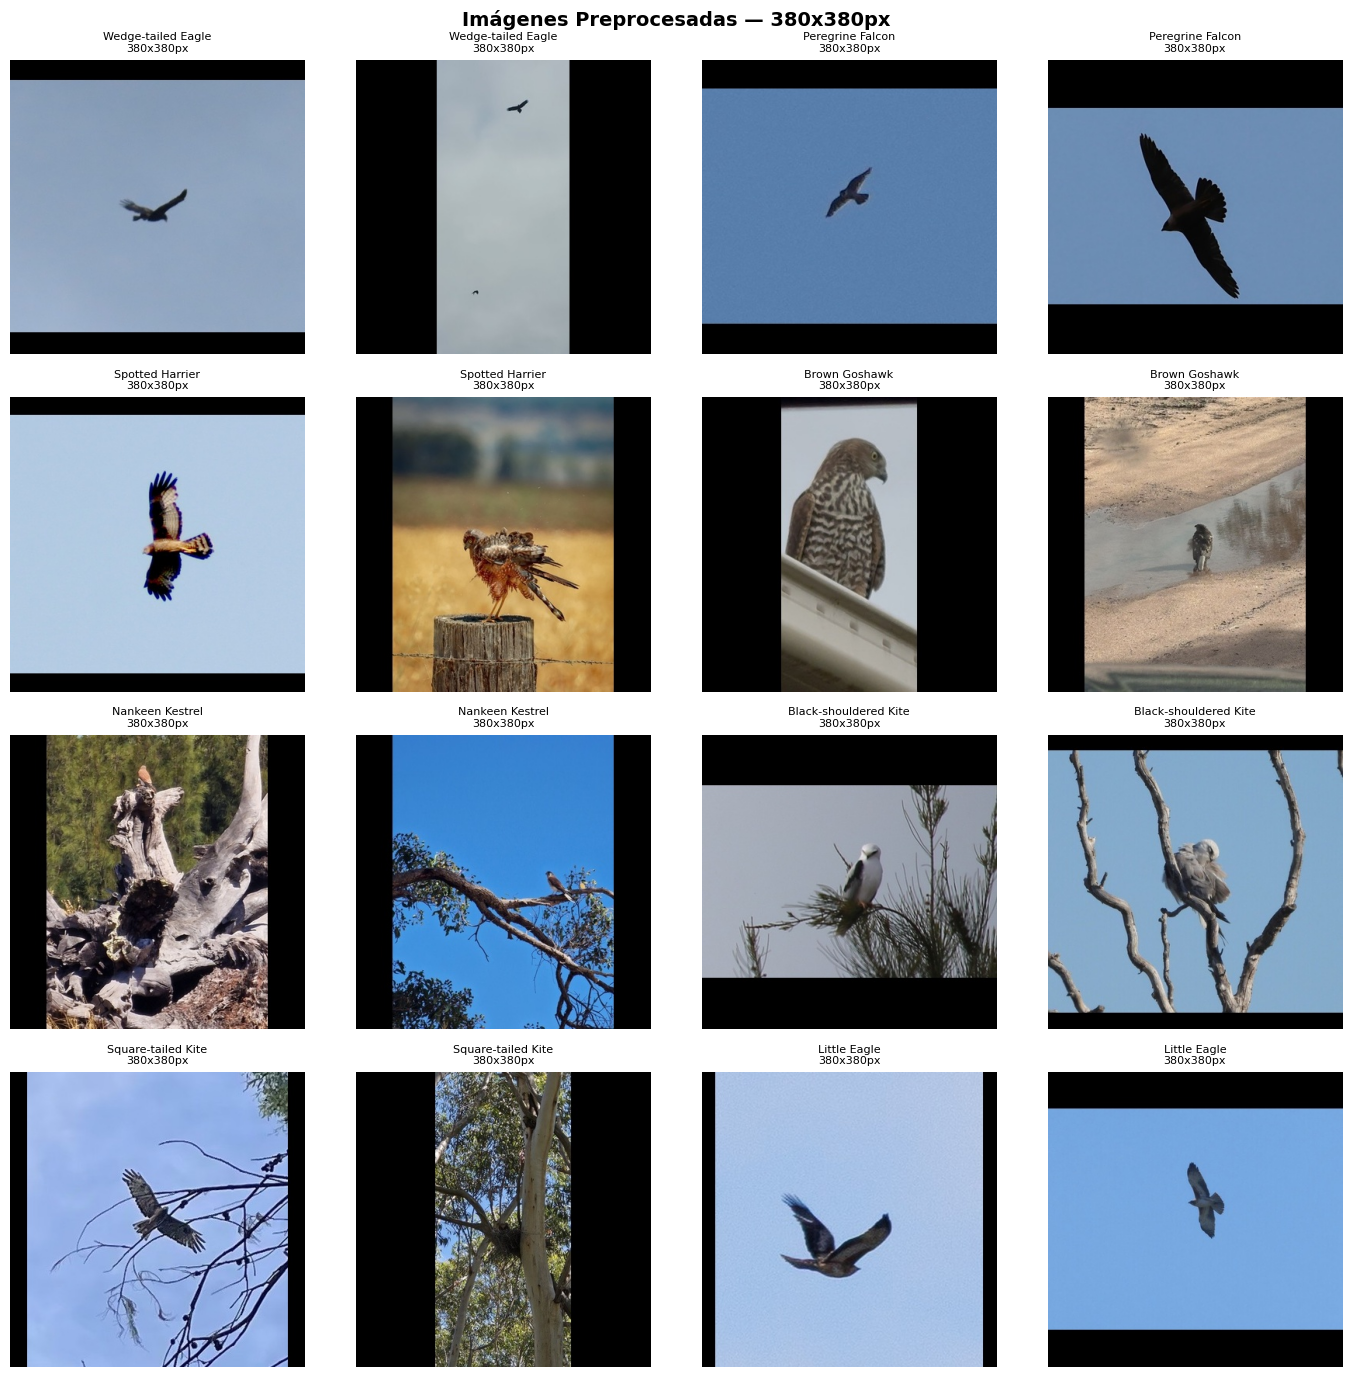

✅ Visualización guardada en results/


In [27]:
print("🖼️  Verificando calidad del preprocesamiento...\n")

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

idx = 0
for key, nombre in SPECIES.items():
    carpeta = PROCESSED_DIR / "train" / key
    imgs    = list(carpeta.glob("*.jpg"))

    if not imgs:
        continue

    # Mostrar 2 imágenes por especie
    for img_path in imgs[:2]:
        if idx >= 16:
            break

        img = mpimg.imread(str(img_path))
        axes[idx].imshow(img)
        axes[idx].set_title(f"{nombre}\n{img.shape[1]}x{img.shape[0]}px",
                            fontsize=8)
        axes[idx].axis("off")
        idx += 1

# Apagar ejes sobrantes
for ax in axes[idx:]:
    ax.axis("off")

plt.suptitle("Imágenes Preprocesadas — 380x380px",
             fontsize=14, fontweight="bold")
plt.tight_layout()

out = PROJECT_ROOT / "results" / "dataset_preprocesado.png"
plt.savefig(str(out), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Visualización guardada en results/")

In [28]:
print("📈 ESTADÍSTICAS FINALES\n")

stats = []
for key, nombre in SPECIES.items():
    row = {"Especie": nombre}
    for split in ["train", "val", "test"]:
        n = len(list(
            (PROCESSED_DIR / split / key).glob("*.jpg")
        ))
        row[split.capitalize()] = n
    row["Total"] = row["Train"] + row["Val"] + row["Test"]
    stats.append(row)

stats_df = pd.DataFrame(stats)

# Agregar fila de totales
totals = {
    "Especie": "TOTAL",
    "Train":   stats_df["Train"].sum(),
    "Val":     stats_df["Val"].sum(),
    "Test":    stats_df["Test"].sum(),
    "Total":   stats_df["Total"].sum()
}
stats_df = pd.concat(
    [stats_df, pd.DataFrame([totals])],
    ignore_index=True
)

print(stats_df.to_string(index=False))

# Guardar
stats_df.to_csv(
    METADATA_DIR / "dataset_final_stats.csv",
    index=False
)

print(f"\n✅ Estadísticas guardadas en metadata/")
print(f"\n🎯 Dataset listo para entrenamiento")

📈 ESTADÍSTICAS FINALES

              Especie  Train  Val  Test  Total
   Wedge-tailed Eagle    285   52    50    387
     Peregrine Falcon    270   56    46    372
      Spotted Harrier    263   52    40    355
        Brown Goshawk    269   57    43    369
      Nankeen Kestrel    300   83    69    452
Black-shouldered Kite    297   78    82    457
   Square-tailed Kite    293   78    81    452
         Little Eagle    292   75    79    446
                TOTAL   2269  531   490   3290

✅ Estadísticas guardadas en metadata/

🎯 Dataset listo para entrenamiento
